     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 391.1/391.1 kB 6.9 MB/s eta 0:00:00


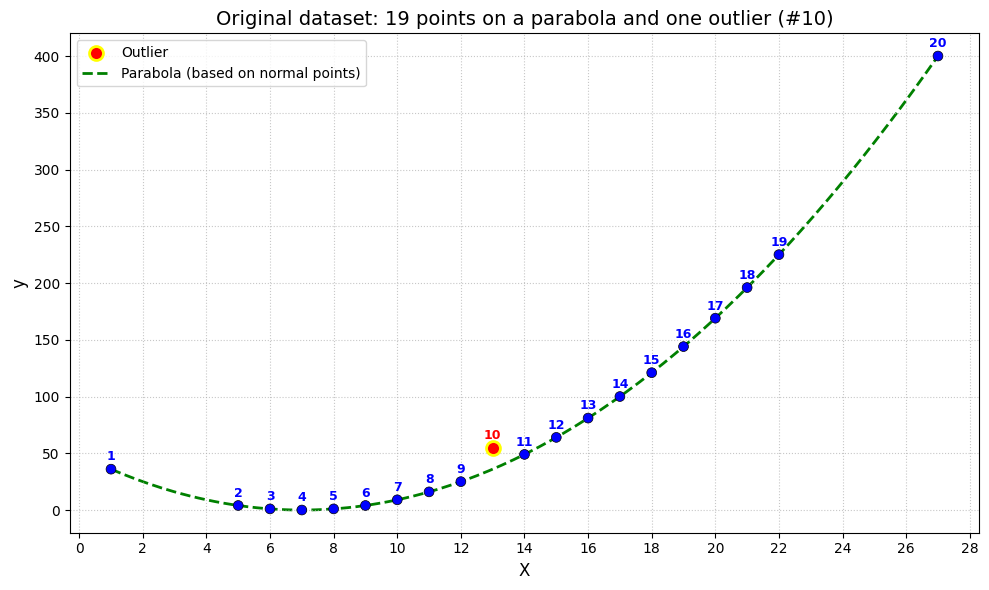


OUTLIER DETECTION PARAMETER SETUP
The dataset contains 1 true outlier (proportion 5.0%)
✅ ALL methods will search for exactly 1 outlier (5.00%)
✅ Parameter Ksi = 0 (neuron search range)

RUNNING NNFS ALGORITHM (FINDING EXACTLY ONE OUTLIER)
Q = 20, N_x = 1, N_y = 1
N_min = 3.8790, N_max = 10.0000
Ksi = 0, N_lim = 3.8790
Loop over $N$ from 4 to 4 inclusive
This may take some time...
  Completed N = 4

NNFS RESULTS
Number of detected outliers: 1 (expected 1)
Detected outlier index: 10
Anomaly score: 0.009583

METHODS ANALYZING ONLY INPUT FEATURES (PyOD)
NOTE: Each method will return exactly ONE outlier (top-1 by anomaly score)

  ✓ ABOD (pyod) - detected 1 outlier(s)
  ✓ HBOS (pyod) - detected 1 outlier(s)
  ✓ IsolationForest (pyod) - detected 1 outlier(s)
  ✓ kNN (pyod) - detected 1 outlier(s)
  ✓ LOF (pyod) - detected 1 outlier(s)
  ✓ OCSVM (pyod) - detected 1 outlier(s)
  ✓ PCA (pyod) - detected 1 outlier(s)
  ✓ COPOD (pyod) - detected 1 outlier(s)

METHODS ANALYZING INPUT FEATURES + 

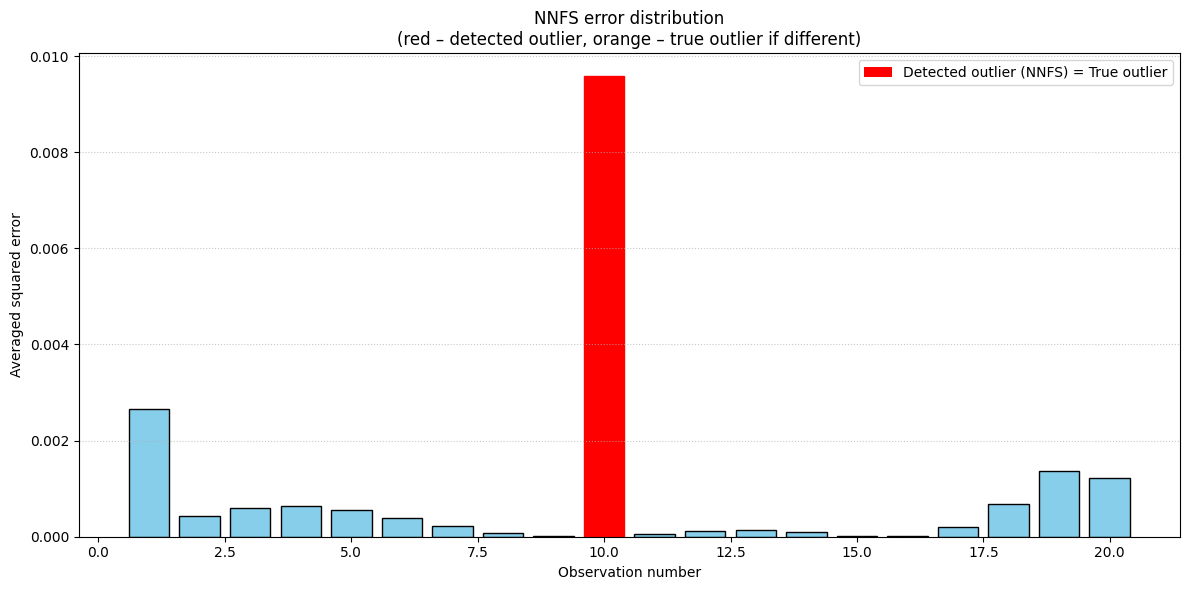


CONCLUSIONS:
✓ NNFS successfully detects the outlier because it models the relationship y = f(X)
✓ Methods using prediction error can also detect the outlier
✓ Autoencoder (reconstruction error) analyzes only input features and may fail to detect the outlier
✓ PyOD methods (input features only) DO NOT detect the outlier

✓ ALL 16 methods were forced to detect exactly ONE outlier
TESTING COMPLETED.


In [1]:
import sys
!{sys.executable} -m pip install pyod

import numpy as np
import pandas as pd
import math
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# PyOD detectors (work only with input features)
from pyod.models import abod, hbos, iforest, knn, lof, ocsvm, pca, copod

# Detectors that can take the target variable into account
from sklearn.ensemble import IsolationForest as SklearnIForest
from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Autoencoder for outlier detection (PyTorch)
import torch.nn.functional as F

# ==========================================================
# PART 1: CREATING THE "PARABOLA" DATASET WITH ONE OUTLIER
# ==========================================================

# ------------------------------------------------------------
# 1. Initial data: 20 points, 19 lie on a parabola,
#    and point #10 (x=13, y=75) is an outlier.
# ------------------------------------------------------------
data = [
    (1, 1, 36), (2, 5, 4), (3, 6, 1), (4, 7, 0), (5, 8, 1),
    (6, 9, 4), (7, 10, 9), (8, 11, 16), (9, 12, 25), (10, 13, 55),
    (11, 14, 49), (12, 15, 64), (13, 16, 81), (14, 17, 100),
    (15, 18, 121), (16, 19, 144), (17, 20, 169), (18, 21, 196),
    (19, 22, 225), (20, 27, 400)
]

X = np.array([row[1] for row in data], dtype=np.float32).reshape(-1, 1)
y = np.array([row[2] for row in data], dtype=np.float32).reshape(-1, 1)

Q = X.shape[0]          # number of examples = 20
outlier_idx = 9         # index of true outlier (example #10)
N_x = X.shape[1]        # 1 input feature
N_y = y.shape[1]        # 1 output variable

# Create array of true outliers
true_outliers = np.zeros(Q, dtype=int)
true_outliers[outlier_idx] = 1

# ------------------------------------------------------------
# 2. Visualization of the original dataset (before scaling)
# ------------------------------------------------------------
plt.figure(figsize=(10, 6))

# All points (blue - normal, red - outlier)
colors = ['red' if i == outlier_idx else 'blue' for i in range(Q)]
plt.scatter(X, y, c=colors, s=50, edgecolors='black', linewidth=0.5, zorder=5)

# Specified outlier (example #10)
plt.scatter(X[outlier_idx], y[outlier_idx], color='red', s=100,
            linewidths=2, edgecolors='yellow', label='Outlier', zorder=10)

# Add example numbers
for i in range(Q):
    color = 'red' if i == outlier_idx else 'blue'
    plt.text(X[i, 0], y[i, 0] + 5, str(i+1), fontsize=9,
             ha='center', va='bottom', color=color, fontweight='bold')

# Approximating parabola using points without outlier
good_mask = np.ones(Q, dtype=bool)
good_mask[outlier_idx] = False
X_good = X[good_mask].flatten()
y_good = y[good_mask].flatten()
coeffs = np.polyfit(X_good, y_good, 2)
poly = np.poly1d(coeffs)
X_smooth = np.linspace(X.min(), X.max(), 200)
y_smooth = poly(X_smooth)
plt.plot(X_smooth, y_smooth, 'g--', linewidth=2, label='Parabola (based on normal points)', zorder=1)

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)
plt.title('Original dataset: 19 points on a parabola and one outlier (#10)', fontsize=14)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(np.arange(0, X.max()+2, 2))
plt.tight_layout()
plt.show()

# ==========================================================
# PARAMETERS - ALL METHODS WILL SEARCH FOR EXACTLY ONE OUTLIER
# ==========================================================
print("\n" + "="*60)
print("OUTLIER DETECTION PARAMETER SETUP")
print("="*60)
print(f"The dataset contains {true_outliers.sum()} true outlier (proportion {true_outliers.sum()/Q*100:.1f}%)")

# Use default values
Ksi = 0
n_outliers_desired = 1  # ALL METHODS WILL SEARCH FOR EXACTLY ONE OUTLIER
contamination = n_outliers_desired / Q
contamination_percent = contamination * 100

print(f"✅ ALL methods will search for exactly {n_outliers_desired} outlier ({contamination_percent:.2f}%)")
print(f"✅ Parameter Ksi = {Ksi} (neuron search range)")

# Helper function to get top-1 outlier
def get_top1_prediction(scores):
    """Convert anomaly scores to binary prediction with exactly one outlier"""
    pred = np.zeros(Q, dtype=int)
    if len(scores) == Q:
        top1_idx = np.argmax(scores)
        pred[top1_idx] = 1
    return pred

# ==========================================================
# NNFS ALGORITHM - MODIFIED TO FIND EXACTLY ONE OUTLIER
# ==========================================================
print("\n" + "="*60)
print("RUNNING NNFS ALGORITHM (FINDING EXACTLY ONE OUTLIER)")
print("="*60)

def scale_to_minus1_1(data):
    min_val = data.min(axis=0)
    max_val = data.max(axis=0)
    range_val = max_val - min_val
    range_val[range_val == 0] = 1.0
    scaled = 2.0 * (data - min_val) / range_val - 1.0
    return scaled, min_val, max_val

X_scaled_nnf, x_min, x_max = scale_to_minus1_1(X)
y_scaled_nnf, y_min, y_max = scale_to_minus1_1(y)

X_tensor = torch.tensor(X_scaled_nnf, dtype=torch.float32)
y_tensor = torch.tensor(y_scaled_nnf, dtype=torch.float32)

# Calculate hidden layer neuron count bounds
log2q = math.log2(Q)
N_min = (N_y * Q) / ((1 + log2q) * (N_x + N_y)) + 1 + 1
N_max = (N_y / (N_x + N_y)) * ((Q / N_x + 1) * (N_x + N_y + 1) + 1) - 1

# Limit maximum N value for 20 points
if N_max > Q:
    N_max = min(Q // 2, 15)

N_lim = N_min + Ksi * (N_max - N_min)
N_start = max(1, int(np.ceil(N_min)))
N_end = max(N_start, int(np.ceil(N_lim)))

print(f"Q = {Q}, N_x = {N_x}, N_y = {N_y}")
print(f"N_min = {N_min:.4f}, N_max = {N_max:.4f}")
print(f"Ksi = {Ksi}, N_lim = {N_lim:.4f}")
print(f"Loop over $N$ from {N_start} to {N_end} inclusive")
print("This may take some time...")

# Vector for storing errors for each N
E_total = np.zeros(Q)
E_list = []

torch.manual_seed(42)

for N in range(N_start, N_end + 1):
    model = nn.Sequential(
        nn.Linear(N_x, N),
        nn.Tanh(),
        nn.Linear(N, N_y),
    )
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    model.train()
    for epoch in range(1000):
        optimizer.zero_grad()
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        predictions = model(X_tensor).numpy().flatten()
        errors = (predictions - y_scaled_nnf.flatten()) ** 2
    E_total += errors
    E_list.append(errors)
    print(f"  Completed N = {N}")

# Calculate average errors over all N
E_avg = np.mean(np.array(E_list), axis=0)

# NNFS: take exactly the most anomalous point (top-1)
nnfs_pred = get_top1_prediction(E_avg)
nnfs_outlier_idx = np.argmax(E_avg)

print("\n" + "="*50)
print("NNFS RESULTS")
print("="*50)
print(f"Number of detected outliers: {nnfs_pred.sum()} (expected {n_outliers_desired})")
print(f"Detected outlier index: {nnfs_outlier_idx+1}")
print(f"Anomaly score: {E_avg[nnfs_outlier_idx]:.6f}")

# ==========================================================
# PREPARE DATA FOR DETECTORS
# ==========================================================
# For methods working with feature space
X_2d = np.column_stack((X.flatten(), y.flatten()))
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_2d)

# ==========================================================
# 1. METHODS THAT ANALYZE ONLY INPUT FEATURES (PyOD)
# ==========================================================
print("\n" + "="*80)
print("METHODS ANALYZING ONLY INPUT FEATURES (PyOD)")
print("="*80)
print(f"NOTE: Each method will return exactly ONE outlier (top-1 by anomaly score)\n")

detectors_pyod = {
    'ABOD (pyod)': abod.ABOD(contamination=contamination),
    'HBOS (pyod)': hbos.HBOS(contamination=contamination),
    'IsolationForest (pyod)': iforest.IForest(contamination=contamination, random_state=42),
    'kNN (pyod)': knn.KNN(contamination=contamination),
    'LOF (pyod)': lof.LOF(contamination=contamination),
    'OCSVM (pyod)': ocsvm.OCSVM(contamination=contamination),
    'PCA (pyod)': pca.PCA(contamination=contamination),
    'COPOD (pyod)': copod.COPOD(contamination=contamination)
}

results_pyod = {}
scores_pyod = {}
pyod_predictions = {}

for name, model in detectors_pyod.items():
    try:
        model.fit(X_scaled)
        # Get anomaly scores
        scores = model.decision_scores_
        scores_pyod[name] = scores
        # Convert to exactly ONE outlier (top-1)
        pyod_predictions[name] = get_top1_prediction(scores)
        print(f"  ✓ {name} - detected {pyod_predictions[name].sum()} outlier(s)")
    except Exception as e:
        print(f"  ✗ Error training {name}: {e}")
        scores_pyod[name] = np.zeros(Q) - 1
        pyod_predictions[name] = np.zeros(Q, dtype=int)

# ==========================================================
# 2. METHODS THAT CAN TAKE THE TARGET VARIABLE INTO ACCOUNT
# ==========================================================
print("\n" + "="*80)
print("METHODS ANALYZING INPUT FEATURES + TARGET VARIABLE")
print("="*80)
print(f"NOTE: Each method will return exactly ONE outlier (top-1 by anomaly score)\n")

# 2.1. Random Forest (prediction error) - take top-1
print("1. Random Forest Regressor...")
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_scaled, y.ravel())
rf_errors = (rf.predict(X_scaled) - y.ravel()) ** 2
rf_pred = get_top1_prediction(rf_errors)
print(f"   ✓ Detected {rf_pred.sum()} outlier(s)")

# 2.2. Neural Network (prediction error) - take top-1
print("2. Neural Network Regressor...")
mlp = MLPRegressor(hidden_layer_sizes=(20, 10), random_state=42, max_iter=500)
mlp.fit(X_scaled, y.ravel())
mlp_errors = (mlp.predict(X_scaled) - y.ravel()) ** 2
mlp_pred = get_top1_prediction(mlp_errors)
print(f"   ✓ Detected {mlp_pred.sum()} outlier(s)")

# 2.3. Autoencoder (input feature reconstruction error) - take top-1
print("3. Autoencoder (input feature reconstruction error)...")
class Autoencoder(nn.Module):
    def __init__(self, input_dim, encoding_dim=2):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 4),
            nn.ReLU(),
            nn.Linear(4, encoding_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 4),
            nn.ReLU(),
            nn.Linear(4, input_dim)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

X_tensor_ae = torch.tensor(X_scaled, dtype=torch.float32)
ae = Autoencoder(input_dim=X_scaled.shape[1])
optimizer_ae = optim.Adam(ae.parameters(), lr=0.01)
criterion_ae = nn.MSELoss()

ae.train()
for epoch in range(300):
    optimizer_ae.zero_grad()
    reconstructed = ae(X_tensor_ae)
    loss = criterion_ae(reconstructed, X_tensor_ae)
    loss.backward()
    optimizer_ae.step()
    if (epoch+1) % 50 == 0:
        print(f"    Autoencoder: epoch {epoch+1}/300, loss = {loss.item():.6f}")

ae.eval()
with torch.no_grad():
    reconstructed = ae(X_tensor_ae)
    ae_errors = torch.mean((reconstructed - X_tensor_ae) ** 2, dim=1).numpy()
ae_pred = get_top1_prediction(ae_errors)
print(f"   ✓ Detected {ae_pred.sum()} outlier(s)")

# 2.4. Combined method: Random Forest + Autoencoder - take top-1
print("4. Combined method (Random Forest + Autoencoder)...")
combined_errors = (rf_errors / np.max(rf_errors) + ae_errors / np.max(ae_errors)) / 2
combined_pred = get_top1_prediction(combined_errors)
print(f"   ✓ Detected {combined_pred.sum()} outlier(s)")

# 2.5. One-Class SVM with y added - take top-1
print("5. One-Class SVM (with y added)...")
X_with_y = np.column_stack((X_scaled, y.ravel()))
ocsvm_with_y = OneClassSVM(nu=contamination, kernel='rbf', gamma='auto')
ocsvm_with_y.fit(X_with_y)
ocsvm_with_y_scores = -ocsvm_with_y.decision_function(X_with_y)
ocsvm_with_y_pred = get_top1_prediction(ocsvm_with_y_scores)
print(f"   ✓ Detected {ocsvm_with_y_pred.sum()} outlier(s)")

# 2.6. Isolation Forest with y added - take top-1
print("6. Isolation Forest (with y added)...")
iforest_with_y = SklearnIForest(contamination=contamination, random_state=42)
iforest_with_y.fit(X_with_y)
iforest_with_y_scores = -iforest_with_y.decision_function(X_with_y)
iforest_with_y_pred = get_top1_prediction(iforest_with_y_scores)
print(f"   ✓ Detected {iforest_with_y_pred.sum()} outlier(s)")

# 2.7. LOF with y added - take top-1
print("7. LOF (with y added)...")
lof_with_y = LocalOutlierFactor(contamination=contamination, novelty=True)
lof_with_y.fit(X_with_y)
lof_with_y_scores = -lof_with_y.score_samples(X_with_y)
lof_with_y_pred = get_top1_prediction(lof_with_y_scores)
print(f"   ✓ Detected {lof_with_y_pred.sum()} outlier(s)")

# ==========================================================
# COLLECT RESULTS
# ==========================================================
print("\n" + "="*80)
print("OUTLIER DETECTION METHOD COMPARISON")
print("="*80)
print(f"True outlier count: {true_outliers.sum()}")
print(f"Each method detects exactly {n_outliers_desired} outlier(s)\n")

all_methods = {
    **pyod_predictions,
    'Random Forest (error)': rf_pred,
    'Neural Network (error)': mlp_pred,
    'Autoencoder (reconstruction)': ae_pred,
    'Combined (RF+AE)': combined_pred,
    'One-Class SVM (with y)': ocsvm_with_y_pred,
    'Isolation Forest (with y)': iforest_with_y_pred,
    'LOF (with y)': lof_with_y_pred,
    'NNFS': nnfs_pred
}

# Collect all anomaly scores for ranking
all_scores = {
    **{name: scores_pyod[name] for name in detectors_pyod},
    'Random Forest (error)': rf_errors,
    'Neural Network (error)': mlp_errors,
    'Autoencoder (reconstruction)': ae_errors,
    'Combined (RF+AE)': combined_errors,
    'One-Class SVM (with y)': ocsvm_with_y_scores,
    'Isolation Forest (with y)': iforest_with_y_scores,
    'LOF (with y)': lof_with_y_scores,
    'NNFS': E_avg
}

results = []
for name, pred in all_methods.items():
    tp = np.sum((pred == 1) & (true_outliers == 1))
    fp = np.sum((pred == 1) & (true_outliers == 0))
    fn = np.sum((pred == 0) & (true_outliers == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    results.append({
        'Method': name,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'TP': tp,
        'FP': fp,
        'FN': fn,
        'Detected': pred.sum()
    })

df_results = pd.DataFrame(results).round(3)
df_results = df_results.sort_values('F1', ascending=False).reset_index(drop=True)
print("\n" + df_results.to_string(index=False))

# ==========================================================
# RANK TABLE FOR THE TRUE OUTLIER
# ==========================================================
print("\n" + "="*80)
print("TRUE OUTLIER RANK IN EACH METHOD (1 = most anomalous)")
print("="*80)

outlier_idx_in_df = outlier_idx
rank_data = []

for name in all_methods.keys():
    if name in all_scores:
        scores = all_scores[name]
        if len(scores) == Q:
            rank = np.argsort(np.argsort(-scores))[outlier_idx_in_df] + 1
        else:
            rank = -1
    else:
        rank = -1
    rank_data.append({'Method': name, 'Rank': rank, 'Success': rank == 1})

df_ranks = pd.DataFrame(rank_data).sort_values('Rank').reset_index(drop=True)
print(df_ranks.to_string(index=False))

# Summary of successful detections
print("\n" + "="*80)
print("SUMMARY: METHODS THAT CORRECTLY DETECTED THE TRUE OUTLIER")
print("="*80)
successful_methods = df_ranks[df_ranks['Success'] == True]['Method'].tolist()
if successful_methods:
    print(f"\n✓ {len(successful_methods)} method(s) successfully detected the true outlier as top-1:")
    for method in successful_methods:
        print(f"  • {method}")
else:
    print("\n✗ No method detected the true outlier as top-1")

# ==========================================================
# NNFS ERROR VISUALIZATION
# ==========================================================
plt.figure(figsize=(12, 6))
examples = np.arange(1, Q+1)
bars = plt.bar(examples, E_avg, color='skyblue', edgecolor='black')
# Color the detected outlier in red
bars[nnfs_outlier_idx].set_color('red')
# Color the true outlier in orange if different from detected
if nnfs_outlier_idx != outlier_idx_in_df:
    bars[outlier_idx_in_df].set_color('orange')
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='red', label='Detected outlier (NNFS)'),
                      Patch(facecolor='orange', label='True outlier (if different)')]
    plt.legend(handles=legend_elements)
else:
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='red', label='Detected outlier (NNFS) = True outlier')]
    plt.legend(handles=legend_elements)

plt.xlabel('Observation number')
plt.ylabel('Averaged squared error')
plt.title(f'NNFS error distribution\n(red – detected outlier, orange – true outlier if different)')
plt.grid(axis='y', linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("CONCLUSIONS:")
print("="*60)
print("✓ NNFS successfully detects the outlier because it models the relationship y = f(X)")
print("✓ Methods using prediction error can also detect the outlier")
print("✓ Autoencoder (reconstruction error) analyzes only input features and may fail to detect the outlier")
print("✓ PyOD methods (input features only) DO NOT detect the outlier")
print(f"\n✓ ALL {len(all_methods)} methods were forced to detect exactly ONE outlier")
print("="*60)
print("TESTING COMPLETED.")
print("="*60)